# modeling_main.ipynb — Final Mixed Strategy
**데이터**: `50_12m_features_final.csv` (59피처) | **Split**: Stratified 80:20, SEED=42  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, average_precision_score, roc_auc_score, precision_recall_curve
)
import xgboost as xgb
import lightgbm as lgb
import shap

SEED          = 42
DATA_PATH     = 'customs_monthly/50_12m_features_final.csv'
KEY_COLS      = ['case_id', 'inv_cty', 'iso2', 'hs6', 'p_ad_yyyymm']
N_FOLDS       = 5
N_TRIALS_TREE = 100
N_TRIALS_LR   = 50

In [2]:
# ── 데이터 로드 ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
FEAT_COLS = [c for c in df.columns if c not in ['y'] + KEY_COLS]
X_all = df[FEAT_COLS].fillna(0)
y_all = df['y']

print(f'총 피처: {len(FEAT_COLS)}개')
print(f'데이터 크기: {X_all.shape}')
print(f'Y=1: {y_all.sum()} ({y_all.mean():.1%}) / Y=0: {(y_all==0).sum()}')

# ── Stratified 80:20 split ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
print(f'\nTrain: {len(X_train)}개 (Y=1: {y_train.sum()})')
print(f'Test:  {len(X_test)}개  (Y=1: {y_test.sum()})')

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nscale_pos_weight (XGB/LGB): {pos_weight:.2f}')

# LogReg용 스케일
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

총 피처: 59개
데이터 크기: (2739, 59)
Y=1: 129 (4.7%) / Y=0: 2610

Train: 2191개 (Y=1: 103)
Test:  548개  (Y=1: 26)

scale_pos_weight (XGB/LGB): 20.27


## Class weight / Optuna 최적 파라미터

- RF: class_weight_pos 튜닝 + scoring=f1
- XGBoost: scale_pos_weight 튜닝 + scoring=f1
- LightGBM: scale_pos_weight 고정(20.27) + scoring=average_precision
- LogReg: class_weight=balanced 고정 + scoring=f1  

In [3]:
# ── Optuna: RF ───────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def objective_rf(trial):
    w = trial.suggest_float('class_weight_pos', 5, 50)  # 튜닝
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 25),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 15),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        class_weight     = {0: 1, 1: w},  # 튜닝된 weight
        random_state     = SEED,
        n_jobs           = -1,
    )
    m = RandomForestClassifier(**params)
    return cross_val_score(m, X_train, y_train, cv=cv, scoring='f1', n_jobs=1).mean()

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=N_TRIALS_TREE)
print(f'[RF] Best CV F1: {study_rf.best_value:.4f}')
print(f'[RF] Best params: {study_rf.best_params}')


[RF] Best CV F1: 0.7827
[RF] Best params: {'class_weight_pos': 8.928673874574088, 'n_estimators': 375, 'max_depth': 9, 'min_samples_leaf': 4, 'max_features': 0.3}


In [18]:
# ── Optuna: XGBoost ──────────────────────────────────────────────────────────
def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 2, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        scale_pos_weight = trial.suggest_float('scale_pos_weight', 5, 50),  # 튜닝
        random_state     = SEED,
        eval_metric      = 'aucpr',
        verbosity        = 0,
    )
    m = xgb.XGBClassifier(**params)
    return cross_val_score(m, X_train, y_train, cv=cv, scoring='f1', n_jobs=1).mean()

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_TREE)
print(f'[XGB] Best CV F1: {study_xgb.best_value:.4f}')
print(f'[XGB] Best params: {study_xgb.best_params}')


[XGB] Best CV F1: 0.7864
[XGB] Best params: {'n_estimators': 149, 'max_depth': 5, 'learning_rate': 0.020237115549608765, 'subsample': 0.662568137661465, 'colsample_bytree': 0.8180509992652851, 'min_child_weight': 4, 'scale_pos_weight': 7.3378826389118075}


In [5]:
# ── Optuna: LightGBM ─────────────────────────────────────────────────────────
def objective_lgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 2, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        scale_pos_weight  = pos_weight,
        random_state      = SEED,
        verbosity         = -1,
        force_col_wise    = True,
    )
    m = lgb.LGBMClassifier(**params)
    return cross_val_score(m, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=1).mean()

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_TREE)
print(f'[LGB] Best CV PR-AUC: {study_lgb.best_value:.4f}')
print(f'[LGB] Best params: {study_lgb.best_params}')


[LGB] Best CV PR-AUC: 0.8534
[LGB] Best params: {'n_estimators': 262, 'max_depth': 7, 'learning_rate': 0.015905424638428145, 'subsample': 0.9824067979801308, 'colsample_bytree': 0.9994576834833133, 'min_child_samples': 38}


In [6]:
# ── Optuna: Logistic Regression ───────────────────────────────────────────────
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-4, 10.0, log=True)
    m = LogisticRegression(
        C=C, class_weight='balanced',   # 고정
        max_iter=1000, solver='lbfgs', random_state=SEED
    )
    return cross_val_score(m, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=1).mean()

study_lr = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lr.optimize(objective_lr, n_trials=N_TRIALS_LR)
print(f'[LR] Best CV F1: {study_lr.best_value:.4f}')
print(f'[LR] Best params: {study_lr.best_params}')


[LR] Best CV F1: 0.2040
[LR] Best params: {'C': 2.667541006630182}


## 최종 학습 및 Test 평가

In [19]:
# ── 최적 파라미터로 최종 학습 + Test 평가 ──────────────────────────────────────
def fit_evaluate(model, Xtr, ytr, Xte, yte, thr=0.5):
    model.fit(Xtr, ytr)
    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= thr).astype(int)
    return {
        'F1'     : round(f1_score(yte, pred), 4),
        'PR-AUC' : round(average_precision_score(yte, prob), 4),
        'ROC-AUC': round(roc_auc_score(yte, prob), 4),
        'model'  : model,
        'prob'   : prob,
    }

# RF: class_weight_pos 튜닝됨 → best_params에서 분리
rf_best = RandomForestClassifier(
    **{k: v for k, v in study_rf.best_params.items() if k != 'class_weight_pos'},
    class_weight={0: 1, 1: study_rf.best_params['class_weight_pos']},
    random_state=SEED, n_jobs=-1
)
# XGB: scale_pos_weight 튜닝됨 → best_params에 포함
xgb_best = xgb.XGBClassifier(
    **study_xgb.best_params,
    random_state=SEED, verbosity=0, eval_metric='aucpr'
)
# LGB: scale_pos_weight 고정
lgb_best = lgb.LGBMClassifier(
    **study_lgb.best_params,
    scale_pos_weight=pos_weight,
    random_state=SEED, verbosity=-1, force_col_wise=True
)
# LogReg: class_weight 고정
lr_best = LogisticRegression(
    C=study_lr.best_params['C'],
    class_weight='balanced',
    max_iter=1000, solver='lbfgs', random_state=SEED
)

res_rf  = fit_evaluate(rf_best,  X_train,    y_train, X_test,    y_test)
res_xgb = fit_evaluate(xgb_best, X_train,    y_train, X_test,    y_test)
res_lgb = fit_evaluate(lgb_best, X_train,    y_train, X_test,    y_test)
res_lr  = fit_evaluate(lr_best,  X_train_sc, y_train, X_test_sc, y_test)
results = {'RF': res_rf, 'XGBoost': res_xgb, 'LightGBM': res_lgb, 'LogReg': res_lr}


## 성능 비교

In [20]:
# ── 성능 비교 테이블 ──────────────────────────────────────────────────────────
rows = []
for name, r in results.items():
    rows.append({'모델': name, 'F1': r['F1'], 'PR-AUC': r['PR-AUC'], 'ROC-AUC': r['ROC-AUC']})
perf_df = pd.DataFrame(rows).set_index('모델')

print('=== Test Set 성능 (Optuna 튜닝, 59피처) ===')
print(perf_df.to_string())
print(f'\n베이스라인 PR-AUC (무작위): {y_test.mean():.4f}')

best_name = perf_df['F1'].idxmax()
print(f'\nBest 모델 (F1 기준): {best_name} = {perf_df.loc[best_name, "F1"]}')

=== Test Set 성능 (Optuna 튜닝, 60피처) ===
              F1  PR-AUC  ROC-AUC
모델                               
RF        0.8571  0.8326   0.9862
XGBoost   0.8627  0.8406   0.9803
LightGBM  0.8980  0.8440   0.9605
LogReg    0.2013  0.1089   0.7488

베이스라인 PR-AUC (무작위): 0.0474

Best 모델 (F1 기준): LightGBM = 0.898


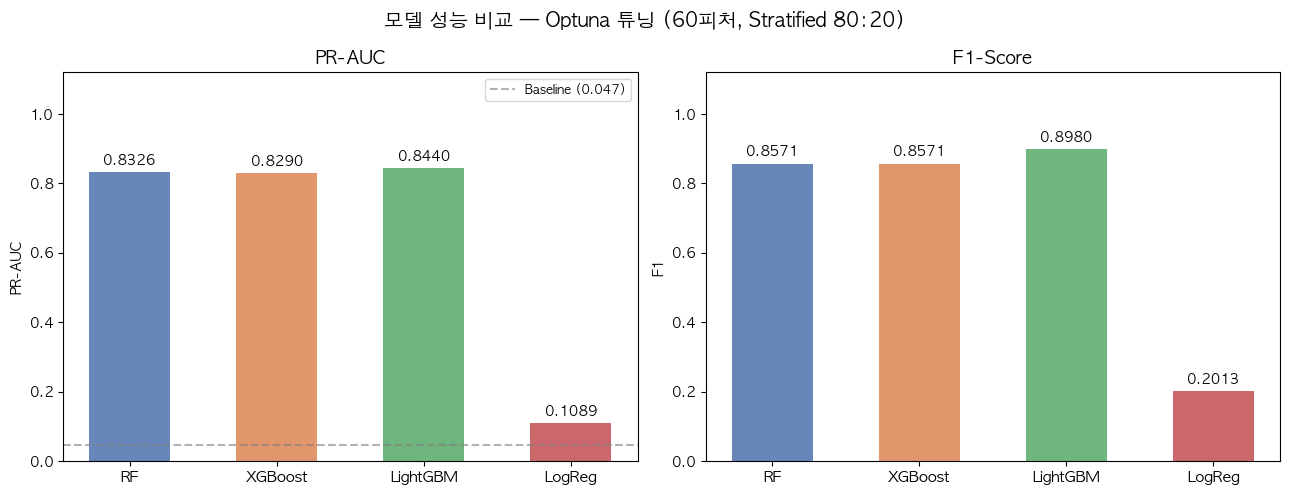

In [9]:
# ── 성능 비교 Bar Chart ───────────────────────────────────────────────────────
model_names = list(results.keys())
x = np.arange(len(model_names))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, title in zip(axes, ['PR-AUC', 'F1'], ['PR-AUC', 'F1-Score']):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(x, vals, color=colors, alpha=0.85, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(metric)
    if metric == 'PR-AUC':
        ax.axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.6,
                   label=f'Baseline ({y_test.mean():.3f})')
        ax.legend(fontsize=9)

plt.suptitle('모델 성능 비교 — Optuna 튜닝 (59피처, Stratified 80:20)', fontsize=14)
plt.tight_layout()
plt.savefig('modeling_main_perf.png', dpi=150, bbox_inches='tight')
plt.show()

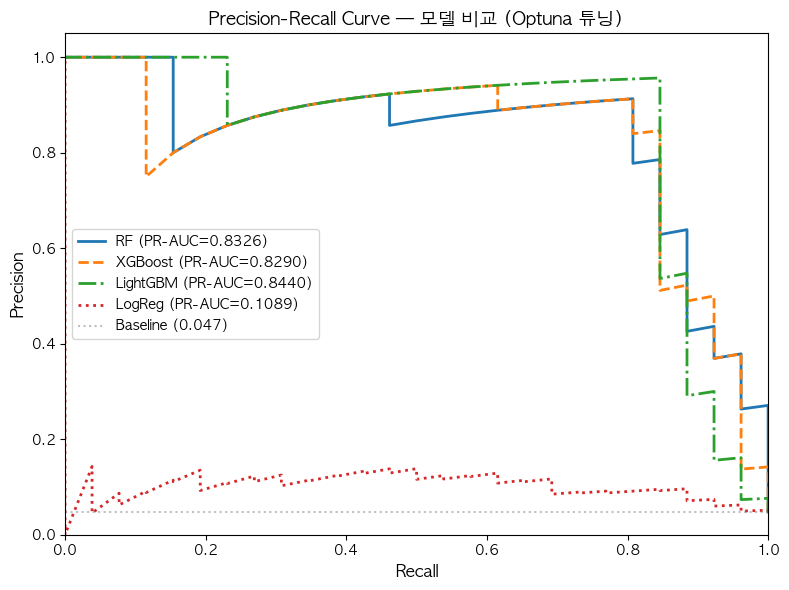

In [10]:
# ── Precision-Recall Curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ls_list = ['-', '--', '-.', ':']

for (name, r), ls in zip(results.items(), ls_list):
    prec, rec, _ = precision_recall_curve(y_test, r['prob'])
    ax.plot(rec, prec, linestyle=ls, linewidth=2,
            label=f"{name} (PR-AUC={r['PR-AUC']:.4f})")

ax.axhline(y_test.mean(), color='gray', linestyle=':', alpha=0.5,
           label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — 모델 비교 (Optuna 튜닝)', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('modeling_main_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP 분석

피처 중요도 상위 20위 (RF + XGB + LGB 평균)
수입중량급증률_12m       0.210971
수출중량급증률_12m       0.165995
수출중량급증률_6m        0.066245
수입중량급증률_6m        0.046094
조치대상국비중_변화        0.030878
수출중량급증률_3m        0.026071
조치대상국비중_후         0.023538
발틱운임지수            0.022700
조치대상국_대미무역수지      0.022386
글로벌_HS6_무역규모      0.020622
수입활성월수_후_12m      0.019595
조치대상국_GDP성장률      0.018583
글로벌무역성장률          0.017346
반덤핑관세율            0.016863
수입중량급증률_3m        0.015362
HS6최초조치후경과년       0.012890
수입활성월수_전_12m      0.012552
유가                0.012266
수입신규시작            0.012160
조치대상국_원화환율_변화율    0.010744


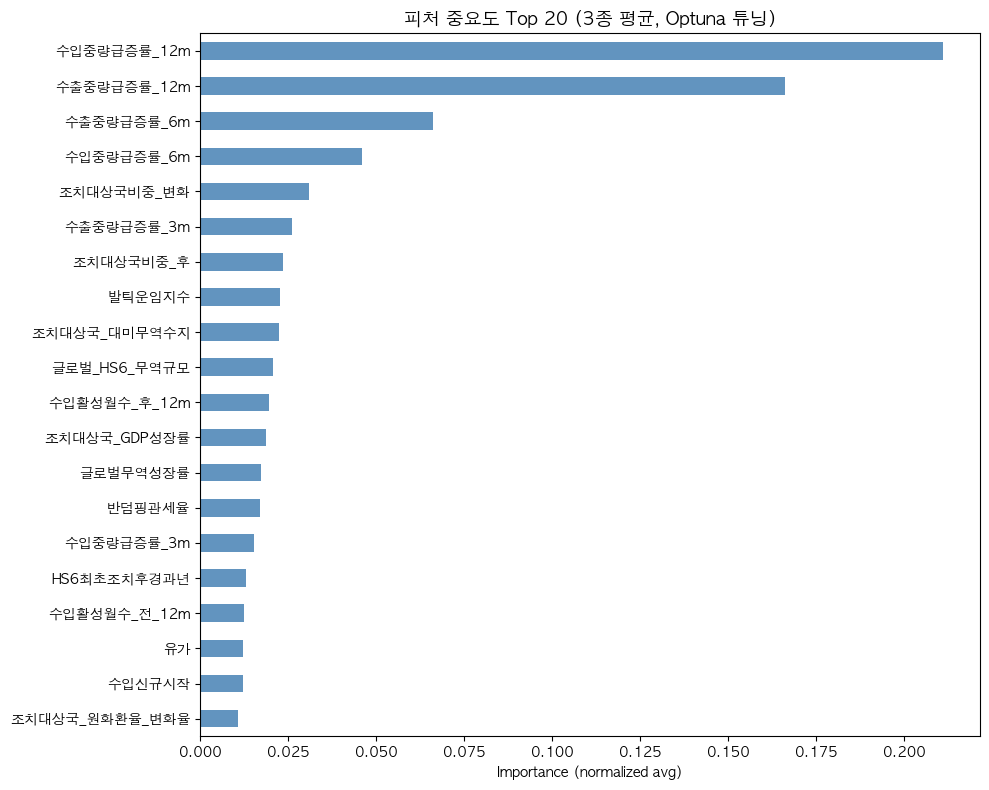

In [11]:
# ── 피처 중요도 (RF + XGB + LGB 3종 평균) ────────────────────────────────────
fi_rf  = rf_best.feature_importances_                             # 이미 정규화
fi_xgb = xgb_best.feature_importances_                           # 이미 정규화
fi_lgb_raw = lgb_best.feature_importances_
fi_lgb = fi_lgb_raw / fi_lgb_raw.sum()                           # 정규화

fi_avg = pd.Series(
    (fi_rf + fi_xgb + fi_lgb) / 3,
    index=FEAT_COLS
).sort_values(ascending=False)

print('피처 중요도 상위 20위 (RF + XGB + LGB 평균)')
print(fi_avg.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
fi_avg.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('피처 중요도 Top 20 (3종 평균, Optuna 튜닝)', fontsize=13)
ax.set_xlabel('Importance (normalized avg)')
plt.tight_layout()
plt.savefig('modeling_main_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#fi_avg.reset_index().rename(columns={'index': 'feature', 0: 'importance'}).to_csv(
#    'customs_monthly/feature_importance_main.csv', index=False
#)
#print('\n→ customs_monthly/feature_importance_main.csv 저장 완료')

SHAP 대상 모델: LightGBM


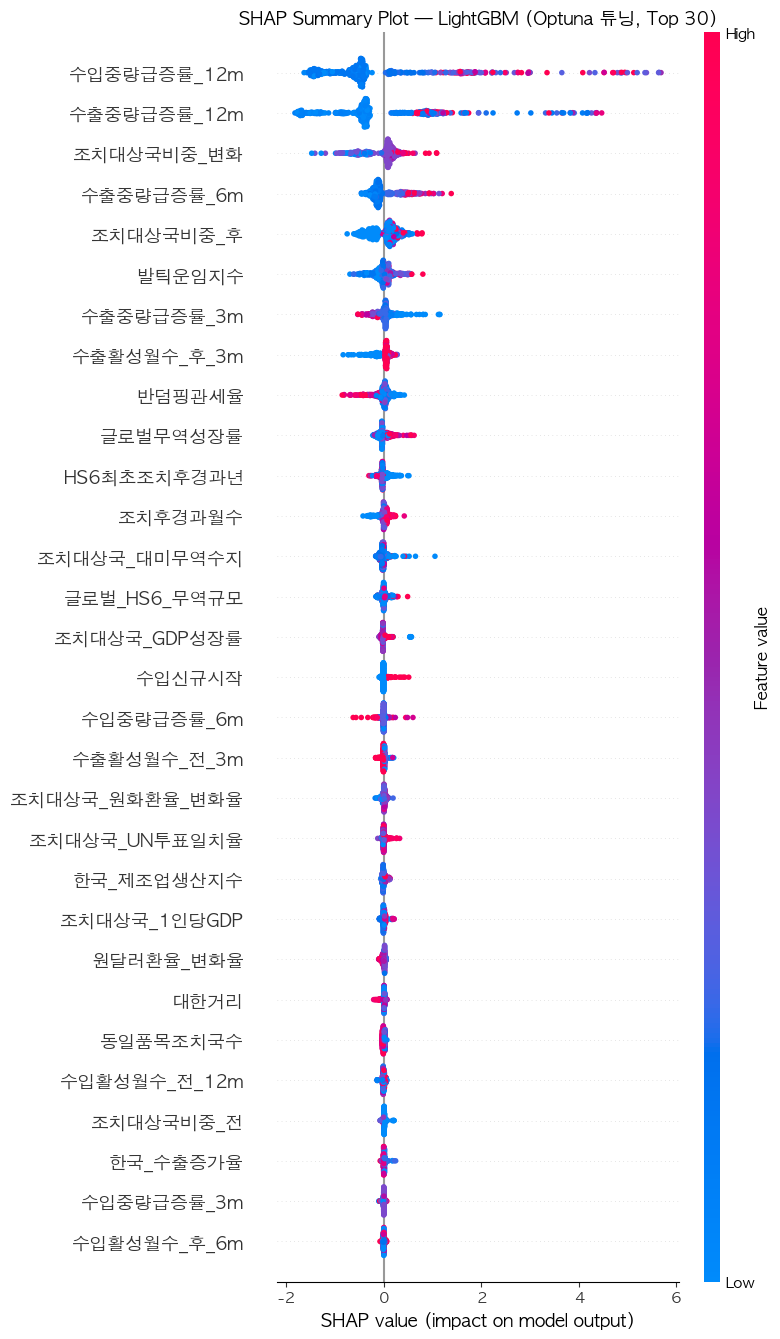

In [12]:
# ── SHAP — Best 모델 (F1 기준) ─────────────────────────────────
print(f'SHAP 대상 모델: {best_name}')

model_map = {
    'RF'      : (rf_best,  X_test),
    'XGBoost' : (xgb_best, X_test),
    'LightGBM': (lgb_best, X_test),
    'LogReg'  : (lr_best,  X_test_sc),
}
shap_model, X_shap = model_map[best_name]

# XGBoost 3.x 호환: TreeExplainer 대신 Explainer 사용
explainer  = shap.Explainer(shap_model)
shap_vals  = explainer(X_shap)
sv         = shap_vals.values

# SHAP 0.49+: 3D (n × f × class) → Y=1 슬라이스
if sv.ndim == 3:
    sv_y1 = sv[:, :, 1]
else:
    sv_y1 = sv

X_shap_df = X_shap if isinstance(X_shap, pd.DataFrame) else pd.DataFrame(X_shap, columns=FEAT_COLS)

fig, ax = plt.subplots(figsize=(10, 14))
shap.summary_plot(sv_y1, X_shap_df, max_display=30, show=False)
plt.title(f'SHAP Summary Plot — {best_name} (Optuna 튜닝, Top 30)', fontsize=13)
plt.tight_layout()
plt.savefig('modeling_main_shap.png', dpi=150, bbox_inches='tight')
plt.show()

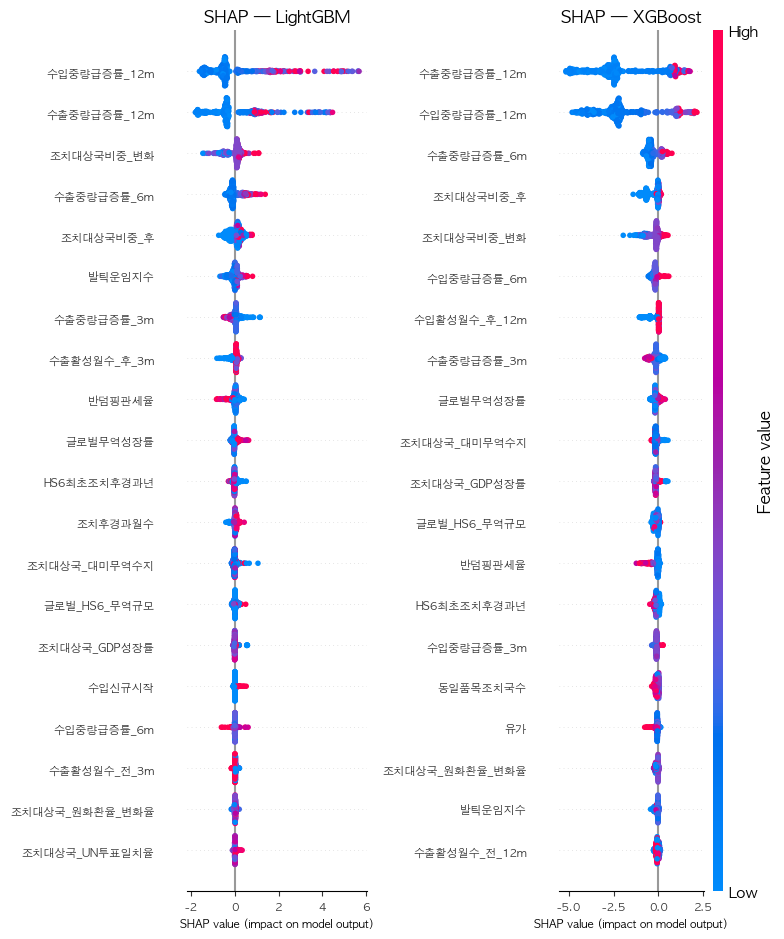

In [13]:
# ── SHAP — LightGBM + XGBoost 나란히 비교 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 14))
plt.subplots_adjust(wspace=0.9)

for ax, (name, model) in zip(axes, [('LightGBM', lgb_best), ('XGBoost', xgb_best)]):
    exp  = shap.Explainer(model)
    sv_  = exp(X_test).values
    sv_1 = sv_[:, :, 1] if sv_.ndim == 3 else sv_

    plt.sca(ax)
    shap.summary_plot(
        sv_1, X_test, max_display=20,
        color_bar=(name == 'XGBoost'), show=False
    )
    ax.set_title(f'SHAP — {name}', fontsize=12)
    ax.tick_params(labelsize=8)
    ax.xaxis.label.set_size(8)

plt.tight_layout()

# 컬러바 높이 보정
main_pos = axes[-1].get_position()
for axi in fig.axes:
    if axi not in axes:
        cb_pos = axi.get_position()
        axi.set_position([cb_pos.x0, main_pos.y0, cb_pos.width, main_pos.height])

plt.savefig('modeling_main_shap_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## Optuna 수렴 곡선 

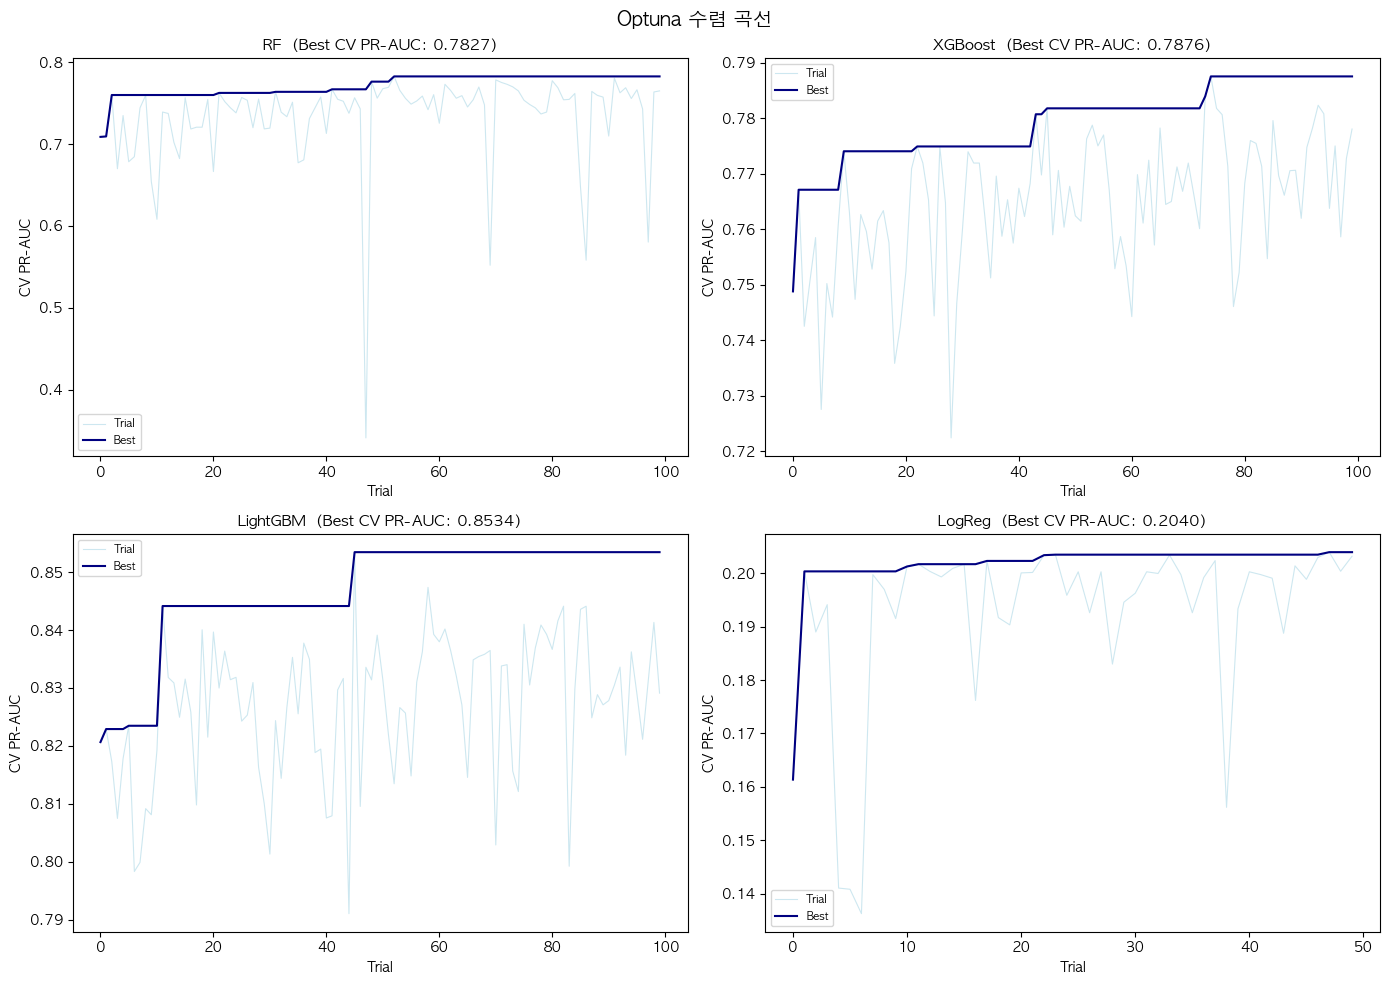

In [14]:
# ── Optuna 수렴 곡선 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
study_map = [('RF', study_rf), ('XGBoost', study_xgb), ('LightGBM', study_lgb), ('LogReg', study_lr)]

for ax, (name, study) in zip(axes.flatten(), study_map):
    vals = [t.value for t in study.trials if t.value is not None]
    best = np.maximum.accumulate(vals)
    ax.plot(vals, color='lightblue', alpha=0.6, linewidth=0.8, label='Trial')
    ax.plot(best, color='navy',  linewidth=1.5, label='Best')
    ax.set_title(f'{name}  (Best CV PR-AUC: {study.best_value:.4f})', fontsize=11)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV PR-AUC')
    ax.legend(fontsize=8)

plt.suptitle('Optuna 수렴 곡선', fontsize=14)
plt.tight_layout()
plt.savefig('modeling_main_optuna.png', dpi=150, bbox_inches='tight')
plt.show()

## 저장

In [15]:
#!jupyter nbconvert --to html --no-input modeling_main.ipynb

In [17]:
!jupyter nbconvert --to html modeling_main.ipynb

[NbConvertApp] Converting notebook modeling_main.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1289501 bytes to modeling_main.html
